# Data Preparation and PCA Workflow
This notebook covers the following steps:
- Importing libraries for data manipulation, visualization, and machine learning.
- Loading and cleaning hospital/patient datasets.
- Encoding categorical variables and scaling features.
- Applying Principal Component Analysis (PCA) for dimensionality reduction.
- Visualizing results and preparing data for downstream ML tasks.
Each section is documented for clarity and reproducibility.

## Library Imports
This cell imports libraries for data manipulation (pandas, numpy), visualization (matplotlib, seaborn), preprocessing (LabelEncoder, scalers), date handling, and PCA. These are essential for the data preparation and dimensionality reduction steps.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler
from datetime import datetime
from sklearn.decomposition import PCA


## Load and Inspect Data
This cell loads the dataset from nanim.csv, saves it to ensure formatting, and displays basic info about the dataframe.

In [ ]:
df = pd.read_csv('nanim.csv',
                 sep=',')

df.to_csv('nanim.csv', index=False)


df = pd.read_csv('nanim.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   subject_id          1383 non-null   int64 
 1   hadm_id             1383 non-null   int64 
 2   admission_type      1383 non-null   object
 3   admission_location  1383 non-null   object
 4   discharge_location  1257 non-null   object
 5   admittime           1383 non-null   object
 6   dischtime           1383 non-null   object
 7   insurance           1383 non-null   object
 8   language            1383 non-null   object
 9   marital_status      1327 non-null   object
 10  race                1383 non-null   object
 11  gender              1383 non-null   object
 12  anchor_age          1383 non-null   int64 
 13  dod                 546 non-null    object
 14  curr_service        1383 non-null   object
 15  careunit            1064 non-null   object
 16  intime              1383

## Handle Missing Values and encode Categorical Data, and scale data
Fills missing values in key categorical columns using the most frequent value or logical defaults, then visualizes their distributions. Goal: Improve data quality and understand category frequencies.

In [ ]:
df.drop_duplicates().head()

,subject_id,hadm_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,language,marital_status,race,gender,anchor_age,dod,curr_service,careunit,intime,outtime,eventtype
0,10004235,24181354,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,2196-02-24 14:38:00,2196-03-04 14:02:00,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,M,47,NaN,MED,NaN,2196-03-04 14:03:01,NaN,discharge
1,10004235,24181354,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,2196-02-24 14:38:00,2196-03-04 14:02:00,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,M,47,NaN,MED,Medicine,2196-02-29 15:58:02,2196-03-04 14:03:01,transfer
2,10004235,24181354,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,2196-02-24 14:38:00,2196-03-04 14:02:00,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,M,47,NaN,MED,Emergency Department,2196-02-24 12:15:00,2196-02-24 17:07:00,ED
3,10004235,24181354,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,2196-02-24 14:38:00,2196-03-04 14:02:00,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,M,47,NaN,MED,Coronary Care Unit (CCU),2196-02-24 17:07:00,2196-02-25 23:35:26,admit
4,10004235,24181354,URGENT,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,2196-02-24 14:38:00,2196-03-04 14:02:00,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,M,47,NaN,MED,Medical Intensive Care Unit (MICU),2196-02-25 23:35:26,2196-02-29 15:58:02,transfer


### Fill Missing Marital Status and discharge location by Mode
Missing values in the marital_status and discharge_location column are filled with the most frequent value (mode). 

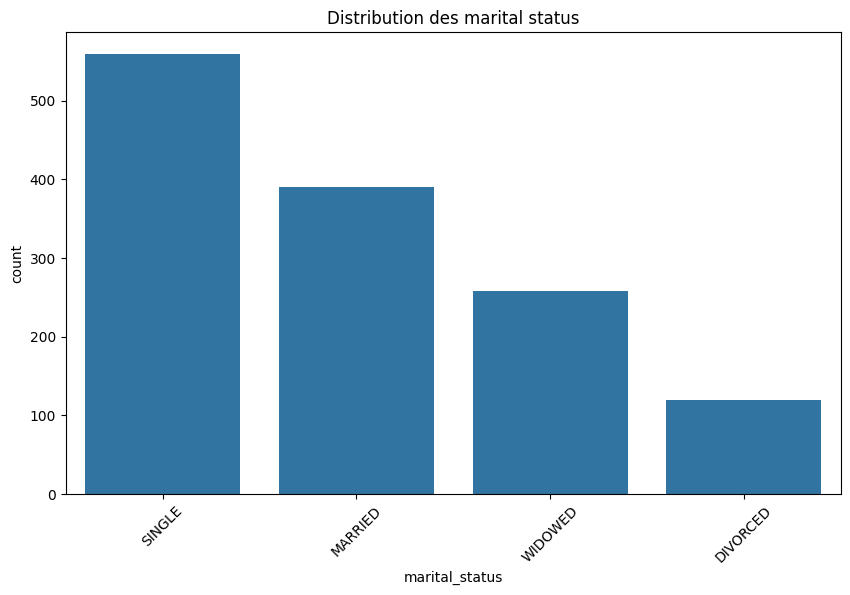

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='marital_status')
plt.xticks(rotation=45)
plt.title('Distribution des marital status')
plt.show()

In [ ]:
most_frequent = df['marital_status'].mode()[0]
df['marital_status'] = df['marital_status'].fillna(most_frequent)

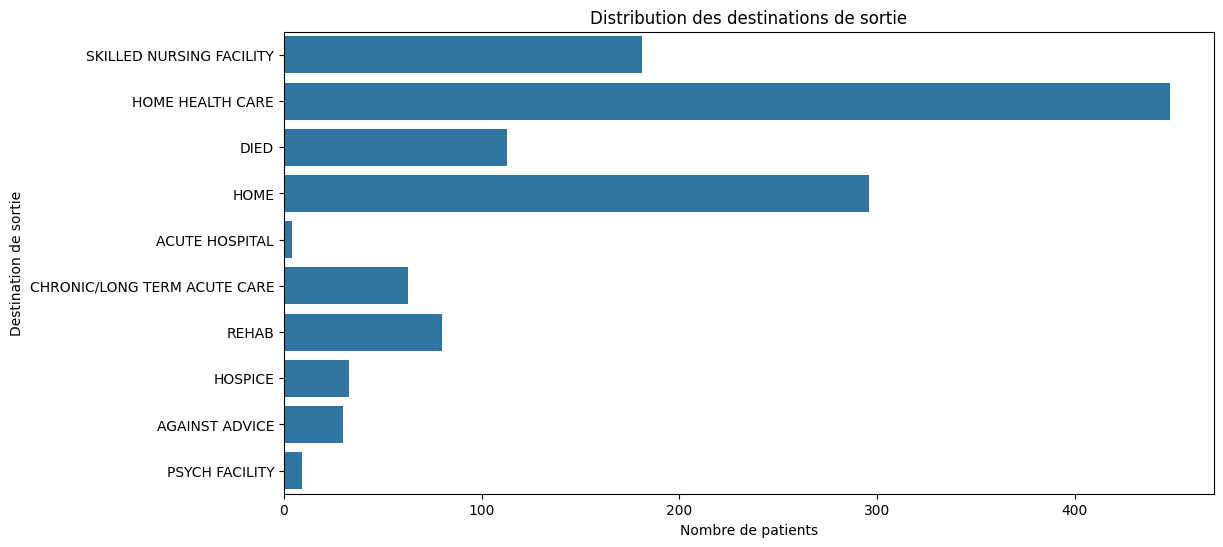

In [ ]:

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='discharge_location')
plt.title('Distribution des destinations de sortie')
plt.xlabel('Nombre de patients')
plt.ylabel('Destination de sortie')
plt.show()

In [ ]:
df['discharge_location'] = df['discharge_location'].fillna('HOME HEALTH CARE') #dischargeloc

### Fill Missing Care Unit by Most Frequent per Service
Missing values in the careunit column are filled with the most frequent care unit for each curr_service. This leverages the typical assignment patterns in the hospital, ensuring logical and consistent imputation.

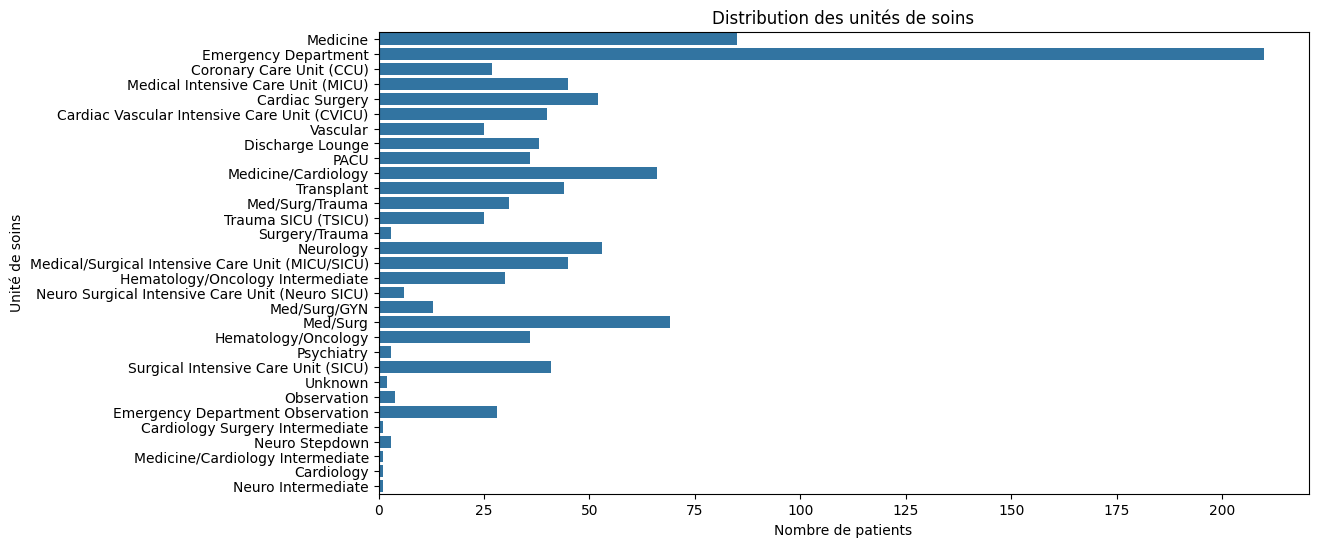


Distribution des unités de soins:
careunit
NaN                                                 319
Emergency Department                                210
Medicine                                             85
Med/Surg                                             69
Medicine/Cardiology                                  66
Neurology                                            53
Cardiac Surgery                                      52
Medical/Surgical Intensive Care Unit (MICU/SICU)     45
Medical Intensive Care Unit (MICU)                   45
Transplant                                           44
Surgical Intensive Care Unit (SICU)                  41
Cardiac Vascular Intensive Care Unit (CVICU)         40
Discharge Lounge                                     38
PACU                                                 36
Hematology/Oncology                                  36
Med/Surg/Trauma                                      31
Hematology/Oncology Intermediate                     30
Emer

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='careunit')
plt.title('Distribution des unités de soins')
plt.xlabel('Nombre de patients')
plt.ylabel('Unité de soins')
plt.show()

print("\nDistribution des unités de soins:")
print(df['careunit'].value_counts(dropna=False))

In [ ]:
#  careunit le plus fréquent pour chaque service
most_frequent_by_service = df.groupby('curr_service')['careunit'].agg(lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
print("\nCareunit le plus fréquent par service:")
print(most_frequent_by_service)



Careunit le plus fréquent par service:
curr_service
CMED                  Medicine/Cardiology
CSURG                     Cardiac Surgery
GYN                          Med/Surg/GYN
MED                  Emergency Department
NMED                            Neurology
NSURG                           Neurology
OMED     Hematology/Oncology Intermediate
ORTHO                     Med/Surg/Trauma
PSYCH                          Psychiatry
SURG                 Emergency Department
TRAUM                     Med/Surg/Trauma
TSURG                    Discharge Lounge
VSURG                            Vascular
Name: careunit, dtype: object


In [ ]:
#careunit
def fill_careunit_by_service(row):
    if pd.isna(row['careunit']):
        service = row['curr_service']
        return df[df['curr_service'] == service]['careunit'].mode()[0]
    return row['careunit']

df['careunit'] = df.apply(fill_careunit_by_service, axis=1)

### Fill Missing Outtime with Dischtime for Discharges
For patients with a missing outtime and an event type of 'discharge', the outtime is set to the dischtime. This ensures that the time a patient left the care unit matches their official discharge time when not recorded.

In [ ]:

df['intime'] = pd.to_datetime(df['intime'])
df['outtime'] = pd.to_datetime(df['outtime'])
df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])

In [ ]:
#outtime
df.loc[(df['outtime'].isnull()) & (df['eventtype'] == 'discharge'), 'outtime'] = df['dischtime']


### Assign Death Status Based on Discharge and Date of Death
Creates a new `death_status` column to clearly indicate patient outcomes:
- If `discharge_location` is 'DIED', the patient died in the hospital before discharge (labeled as 'Hospital Death').
- If a date of death (`dod`) is present but `discharge_location` is not 'DIED', the patient was discharged alive but died later (labeled as 'Post-Discharge Death').
- Otherwise, the patient is considered alive ('Alive').

This distinction helps clarify whether a patient died during their hospital stay or after being discharged, which is important for outcome analysis and modeling.

In [ ]:

print("Distribution des discharge_location pour les patients avec dod:")
print(df[df['dod'].notna()].groupby('discharge_location')['subject_id'].nunique())

#deathstatus
df['death_status'] = 'Alive'

df.loc[df['discharge_location'] == 'DIED', 'death_status'] = 'Hospital Death'
df.loc[(df['dod'].notna()) & (df['discharge_location'] != 'DIED'), 'death_status'] = 'Post-Discharge Death'



Distribution des discharge_location pour les patients avec dod:
discharge_location
CHRONIC/LONG TERM ACUTE CARE     4
DIED                            15
HOME                            11
HOME HEALTH CARE                11
HOSPICE                          5
PSYCH FACILITY                   1
REHAB                            1
SKILLED NURSING FACILITY         7
Name: subject_id, dtype: int64


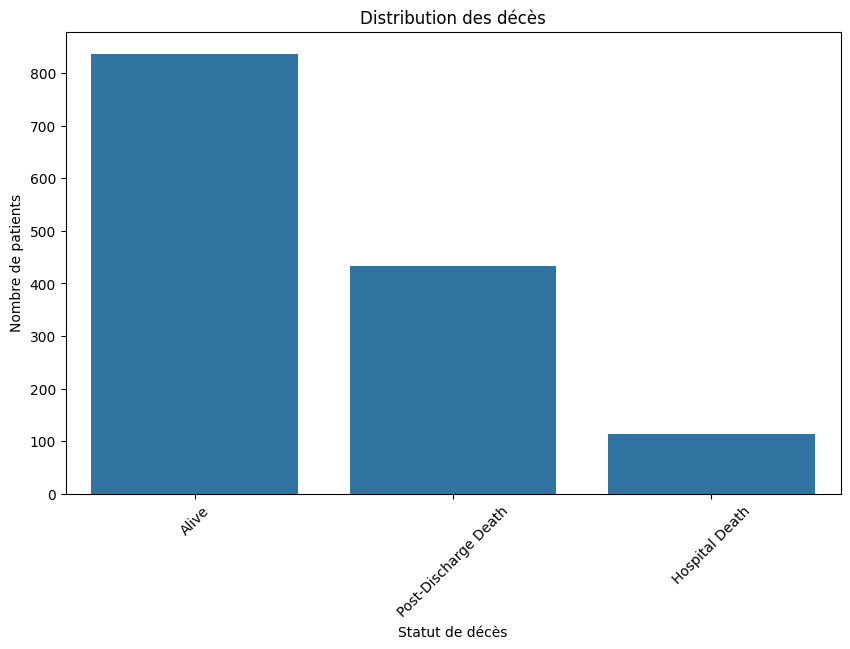

In [ ]:

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='death_status')
plt.title('Distribution des décès')
plt.xlabel('Statut de décès')
plt.ylabel('Nombre de patients')
plt.xticks(rotation=45)
plt.show()

### Remove Date of Death Column After Use
Once the death_status column is created, the dod column is no longer needed and is dropped to keep the dataset clean.

In [ ]:
df = df.drop('dod', axis=1)

### Feature Engineering: Length of Stay
Now that missing values and outcome labels are handled, we create new features to better describe patient stays:
- `los_unit`: Calculates the length of stay in each care unit (in hours) by subtracting `intime` from `outtime`.
- `los_total`: Calculates the total hospital stay (in hours) by subtracting `admittime` from `dischtime`.

These features are important for analyzing patient flow, resource utilization, and for downstream modeling.

### Calculate Length of Stay in Care Unit
Computes the length of stay in each care unit (los_unit) as the difference between outtime and intime, in hours. This is important for analyzing patient flow and resource use.

In [ ]:
df['los_unit'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600

### Calculate Total Hospital Length of Stay
Computes the total length of stay (los_total) as the difference between dischtime and admittime, in hours. This provides a measure of the patient’s entire hospital stay.

In [ ]:
df['los_total'] = (df['dischtime'] - df['admittime']).dt.total_seconds() / 3600

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1383 entries, 0 to 1382
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   subject_id          1383 non-null   int64         
 1   hadm_id             1383 non-null   int64         
 2   admission_type      1383 non-null   object        
 3   admission_location  1383 non-null   object        
 4   discharge_location  1257 non-null   object        
 5   admittime           1383 non-null   datetime64[ns]
 6   dischtime           1383 non-null   datetime64[ns]
 7   insurance           1383 non-null   object        
 8   language            1383 non-null   object        
 9   marital_status      1327 non-null   object        
 10  race                1383 non-null   object        
 11  gender              1383 non-null   object        
 12  anchor_age          1383 non-null   int64         
 13  curr_service        1383 non-null   object      

### Visualize Age Distribution
We visualize the distribution of patient ages using histograms and boxplots. This helps identify outliers, skewness, and the general age profile of the dataset, which can be important for downstream analysis and modeling.

Text(0.5, 0, 'Âge')

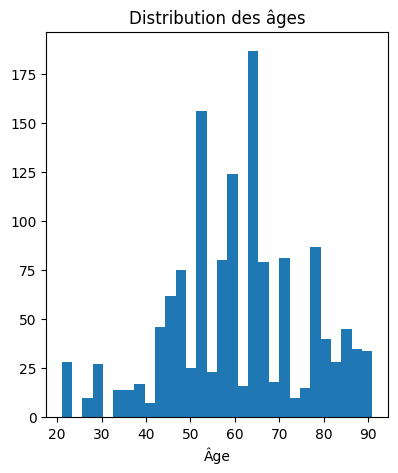

In [ ]:
plt.figure(figsize=(15, 5))

# Age si'il ya valeurs extremes
plt.subplot(1, 3, 1)
plt.hist(df['anchor_age'], bins=30)
plt.title('Distribution des âges')
plt.xlabel('Âge')

### Identify Categorical Variables
We identify columns with object (categorical) data types. This step is necessary to determine which features require encoding before they can be used in machine learning models.

In [ ]:
# 2. Voir les variables de type 'object' (catégorielles)
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index(['admission_type', 'admission_location', 'discharge_location',
       'insurance', 'language', 'marital_status', 'race', 'gender',
       'curr_service', 'careunit', 'eventtype', 'death_status'],
      dtype='object')


### Encode Categorical Variables
We use Label Encoding to convert categorical variables into numeric codes. This transformation is required for most machine learning algorithms, which cannot handle non-numeric data directly.

In [ ]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['death_status'] = le.fit_transform(df['death_status'])
df['admission_type'] = le.fit_transform(df['admission_type'])
df['admission_location'] = le.fit_transform(df['admission_location'])
df['discharge_location'] = le.fit_transform(df['discharge_location'])
df['insurance'] = le.fit_transform(df['insurance'])
df['language'] = le.fit_transform(df['language'])
df['marital_status'] = le.fit_transform(df['marital_status'])
df['race'] = le.fit_transform(df['race'])
df['curr_service'] = le.fit_transform(df['curr_service'])
df['careunit'] = le.fit_transform(df['careunit'])
df['eventtype'] = le.fit_transform(df['eventtype'])

### Check for Remaining Categorical Variables
After encoding, we check if any object-type columns remain. This ensures all features are numeric and ready for further processing or modeling.

In [ ]:
# 2. Voir les variables de type 'object' (catégorielles)
categorical_columns = df.select_dtypes(include=['object']).columns
print(categorical_columns)

Index([], dtype='object')


In [ ]:
df.head(20)

,subject_id,hadm_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,language,marital_status,...,gender,anchor_age,curr_service,careunit,intime,outtime,eventtype,death_status,los_unit,los_total
0,10004235,24181354,8,7,9,2196-02-24 14:38:00,2196-03-04 14:02:00,0,1,2,...,1,47,3,6,2196-03-04 14:03:01,2196-03-04 14:02:00,2,0,-0.016944,215.400000
1,10004235,24181354,8,7,9,2196-02-24 14:38:00,2196-03-04 14:02:00,0,1,2,...,1,47,3,15,2196-02-29 15:58:02,2196-03-04 14:03:01,3,0,94.083056,215.400000
2,10004235,24181354,8,7,9,2196-02-24 14:38:00,2196-03-04 14:02:00,0,1,2,...,1,47,3,6,2196-02-24 12:15:00,2196-02-24 17:07:00,0,0,4.866667,215.400000
3,10004235,24181354,8,7,9,2196-02-24 14:38:00,2196-03-04 14:02:00,0,1,2,...,1,47,3,4,2196-02-24 17:07:00,2196-02-25 23:35:26,1,0,30.473889,215.400000
4,10004235,24181354,8,7,9,2196-02-24 14:38:00,2196-03-04 14:02:00,0,1,2,...,1,47,3,13,2196-02-25 23:35:26,2196-02-29 15:58:02,3,0,88.376667,215.400000
5,10009628,25926192,8,7,5,2153-09-17 17:08:00,2153-09-25 13:20:00,0,0,1,...,1,58,1,0,2153-09-25 13:24:22,2153-09-25 13:20:00,2,0,-0.072778,188.200000
6,10009628,25926192,8,7,5,2153-09-17 17:08:00,2153-09-25 13:20:00,0,0,1,...,1,58,1,0,2153-09-17 17:08:47,2153-09-19 09:54:49,1,0,40.767222,188.200000
7,10009628,25926192,8,7,5,2153-09-17 17:08:00,2153-09-25 13:20:00,0,0,1,...,1,58,1,0,2153-09-21 16:39:06,2153-09-25 13:24:22,3,0,92.754444,188.200000
8,10009628,25926192,8,7,5,2153-09-17 17:08:00,2153-09-25 13:20:00,0,0,1,...,1,58,1,1,2153-09-19 09:54:49,2153-09-21 16:39:06,3,0,54.738056,188.200000
9,10018081,23983182,8,7,9,2134-08-18 02:02:00,2134-08-23 19:35:00,1,1,1,...,1,79,9,6,2134-08-23 19:35:09,2134-08-23 19:35:00,2,2,-0.002500,137.550000


### Outlier Correction for Length of Stay
To ensure data quality, we correct outliers in the length of stay features:
- Negative values in `los_unit` are converted to positive (absolute value).
- Very short stays (<1 hour) are identified and adjusted.
- Extreme values are capped using the interquartile range (IQR) method.

These corrections help prevent skewed analyses and improve model performance.

In [ ]:
print("Nombre de valeurs négatives dans los_unit:", (df['los_unit'] < 0).sum())
print("\nValeurs négatives dans los_unit:")
print(df[df['los_unit'] < 0]['los_unit'])

Nombre de valeurs négatives dans los_unit: 319

Valeurs négatives dans los_unit:
0      -0.016944
5      -0.072778
9      -0.002500
12     -1.019444
16     -0.016111
          ...   
1360   -0.008056
1364   -0.065278
1369   -0.369167
1375   -0.247500
1380   -0.092778
Name: los_unit, Length: 319, dtype: float64


In [ ]:
df['los_unit'] = np.abs(df['los_unit'])

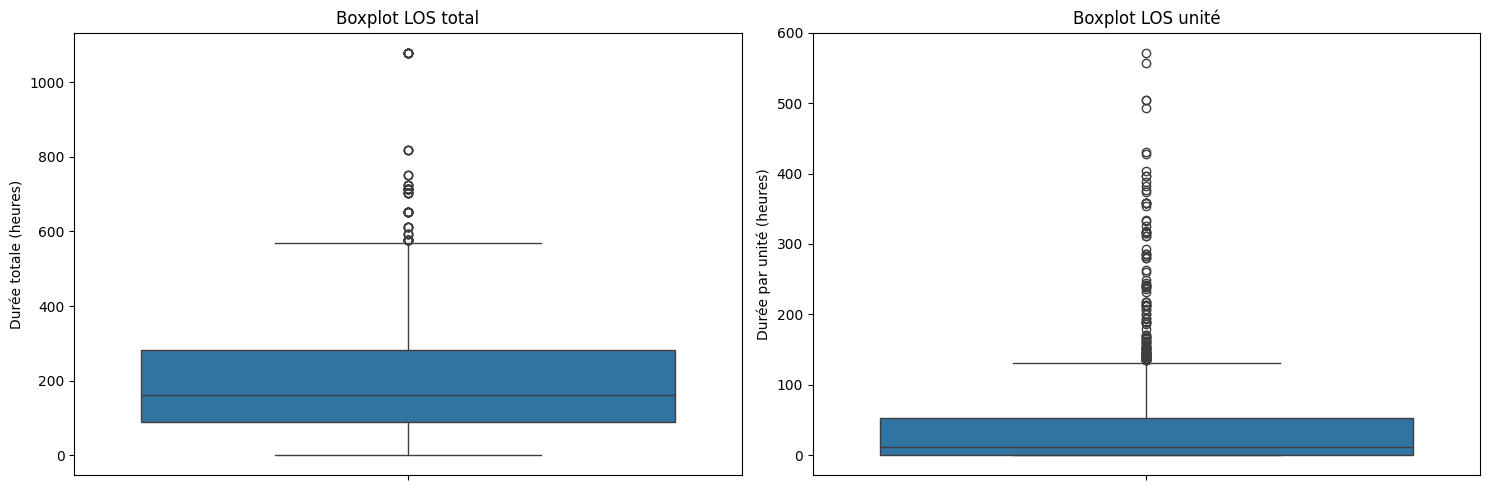

In [ ]:
# 1. Créer les boxplots
plt.figure(figsize=(15, 5))

# LOS total
plt.subplot(1, 2, 1)
sns.boxplot(y=df['los_total'])
plt.title('Boxplot LOS total')
plt.ylabel('Durée totale (heures)')

# LOS unit
plt.subplot(1, 2, 2)
sns.boxplot(y=df['los_unit'])
plt.title('Boxplot LOS unité')
plt.ylabel('Durée par unité (heures)')

plt.tight_layout()
plt.show()

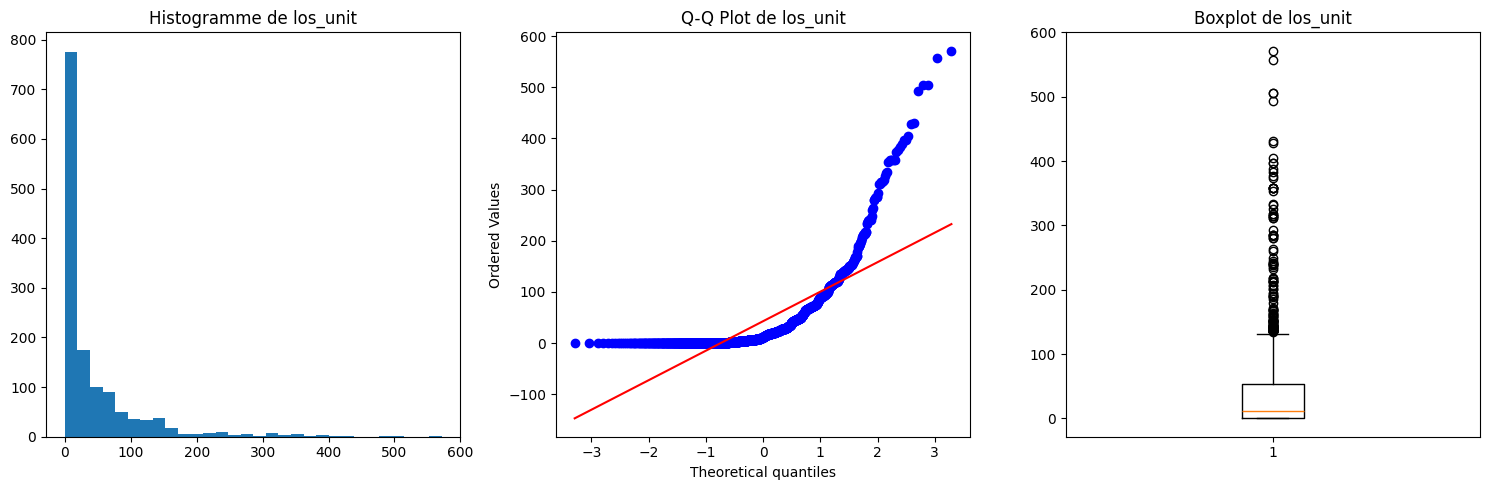


Test de normalité:
p-value: 3.5527996471833033e-205

Statistiques descriptives:
count    1383.000000
mean       42.789887
std        73.404228
min         0.001667
25%         0.758333
50%        11.580278
75%        52.857222
max       571.591111
Name: los_unit, dtype: float64

Skewness: 3.126659790891474
Kurtosis: 12.323115469161351


In [ ]:
import scipy.stats as stats

# 1. Visualisations
plt.figure(figsize=(15, 5))

# Histogramme
plt.subplot(1, 3, 1)
plt.hist(df['los_unit'], bins=30)
plt.title('Histogramme de los_unit')

# Q-Q plot
plt.subplot(1, 3, 2)
stats.probplot(df['los_unit'], dist="norm", plot=plt)
plt.title('Q-Q Plot de los_unit')

# Boxplot
plt.subplot(1, 3, 3)
plt.boxplot(df['los_unit'])
plt.title('Boxplot de los_unit')

plt.tight_layout()
plt.show()

# 2. Test de normalité
stat, p_value = stats.normaltest(df['los_unit'])
print('\nTest de normalité:')
print(f'p-value: {p_value}')

# 3. Statistiques descriptives
print('\nStatistiques descriptives:')
print(df['los_unit'].describe())
print('\nSkewness:', df['los_unit'].skew())
print('Kurtosis:', df['los_unit'].kurtosis())

In [ ]:
#los_unit<60min
short_stays = df[df['los_unit'] < 1][['subject_id', 'los_unit', 'curr_service', 'careunit']]
short_stays['minutes'] = short_stays['los_unit'] * 60


short_stays_sorted = short_stays.sort_values('los_unit')


print(f"Nombre de sejours < 60 minutes: {len(short_stays)}")



Nombre de sejours < 60 minutes: 367


Avant correction:
Nombre de séjours < 1 heure: 367

Après correction:
Nombre de séjours < 1 heure: 0


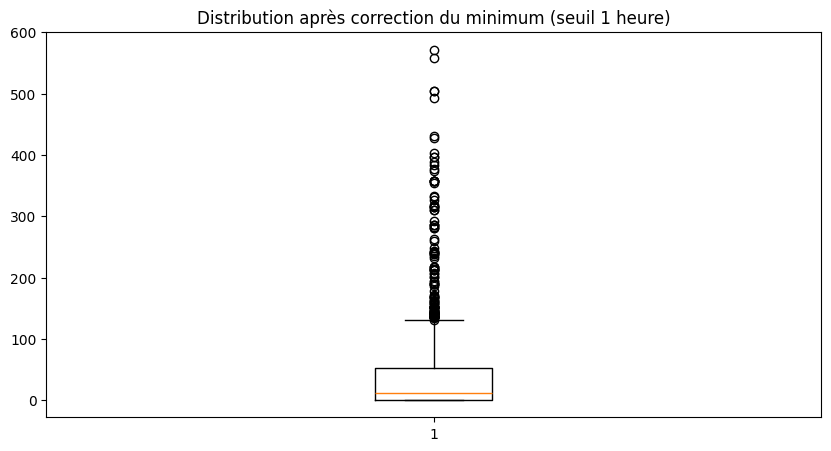

In [ ]:

min_seuil = 1.0  # 1 heure
df['los_unit_clean'] = df['los_unit'].clip(lower=min_seuil)


print("Avant correction:")
print("Nombre de séjours < 1 heure:", (df['los_unit'] < 1.0).sum())
print("\nAprès correction:")
print("Nombre de séjours < 1 heure:", (df['los_unit_clean'] < 1.0).sum())


plt.figure(figsize=(10, 5))
plt.boxplot(df['los_unit_clean'])
plt.title('Distribution après correction du minimum (seuil 1 heure)')
plt.show()

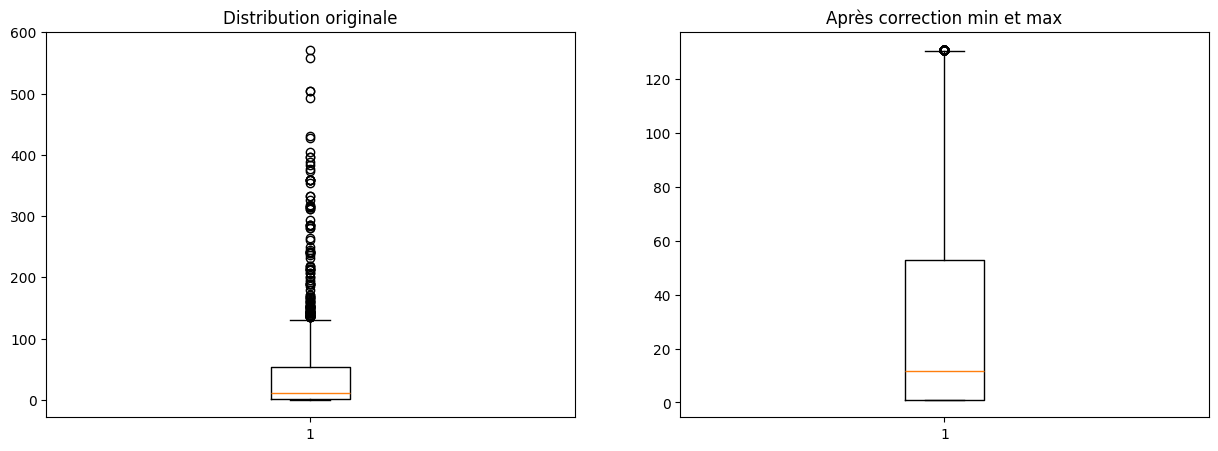

In [ ]:
#IQR
Q1 = df['los_unit'].quantile(0.25)
Q3 = df['los_unit'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR


df['los_unit_clean'] = df['los_unit'].clip(lower=1.0, upper=upper_bound)


plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['los_unit'])
plt.title('Distribution originale')
plt.subplot(1, 2, 2)
plt.boxplot(df['los_unit_clean'])
plt.title('Après correction min et max')
plt.show()

### treating outliers Los_total

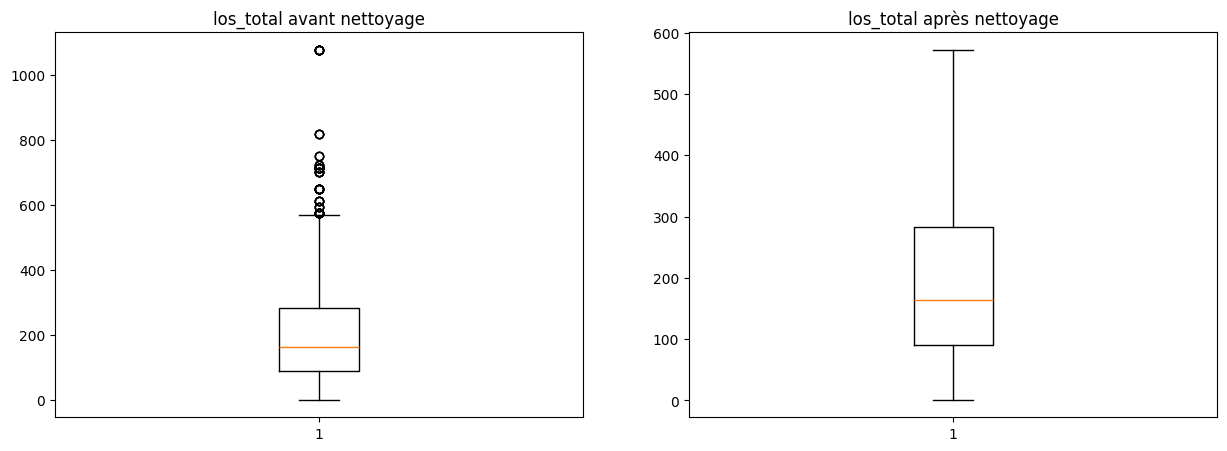

In [ ]:

Q1_total = df['los_total'].quantile(0.25)
Q3_total = df['los_total'].quantile(0.75)
IQR_total = Q3_total - Q1_total
upper_bound_total = Q3_total + 1.5 * IQR_total


df['los_total_clean'] = df.apply(lambda row: max(
    row['los_unit_clean'],
    min(row['los_total'], upper_bound_total)
), axis=1)


plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.boxplot(df['los_total'])
plt.title('los_total avant nettoyage')

plt.subplot(1, 2, 2)
plt.boxplot(df['los_total_clean'])
plt.title('los_total après nettoyage')

plt.show()

In [ ]:

# 2. Afficher quelques statistiques de vérification
print("Vérification los_total >= los_unit:")
print((df['los_total_clean'] >= df['los_unit_clean']).value_counts())

print("\nStatistiques los_unit_clean:")
print(df['los_unit_clean'].describe())

print("\nStatistiques los_total_clean:")
print(df['los_total_clean'].describe())

Vérification los_total >= los_unit:
True    1383
Name: count, dtype: int64

Statistiques los_unit_clean:
count    1383.000000
mean       34.025940
std        43.243419
min         1.000000
25%         1.000000
50%        11.580278
75%        52.857222
max       131.005556
Name: los_unit_clean, dtype: float64

Statistiques los_total_clean:
count    1383.000000
mean      202.250516
std       153.406195
min         1.116667
25%        89.966667
50%       163.066667
75%       282.783333
max       572.008333
Name: los_total_clean, dtype: float64


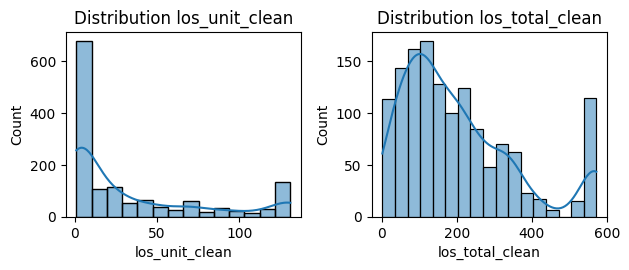

In [ ]:
from scipy import stats


plt.subplot(2, 2, 3)
sns.histplot(df['los_unit_clean'], kde=True)
plt.title('Distribution los_unit_clean')

plt.subplot(2, 2, 4)
sns.histplot(df['los_total_clean'], kde=True)
plt.title('Distribution los_total_clean')

plt.tight_layout()
plt.show()

### Feature Scaling
After cleaning, we scale the features to a standard range using MinMaxScaler. This normalization ensures that all features contribute equally to downstream analyses and machine learning models.


Ranges après scaling:
los_unit: min=-1.000, max=1.000
los_total: min=-1.000, max=1.000


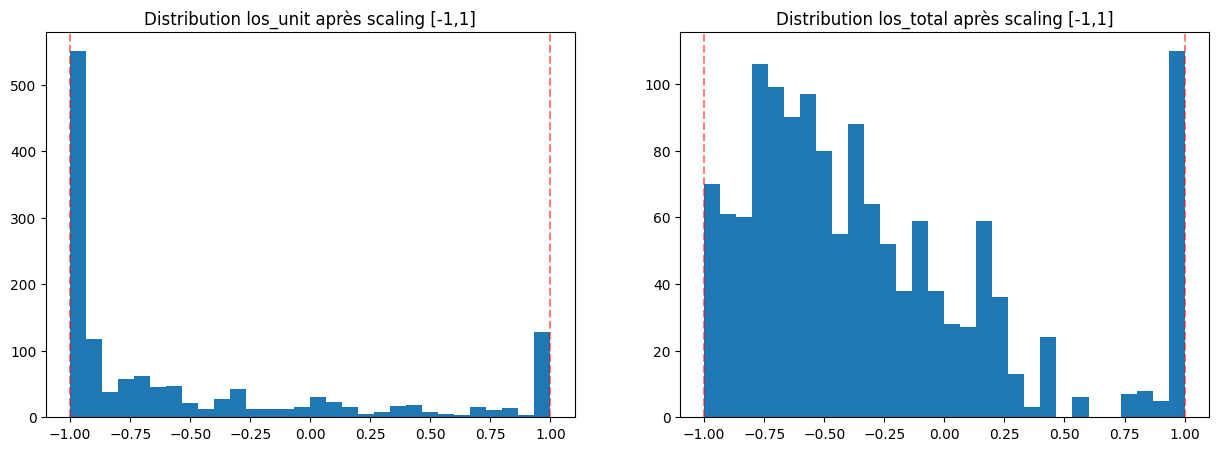

In [ ]:
# 1. MinMaxScaling avec feature_range=(-1,1)
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_values = scaler.fit_transform(df[['los_unit_clean', 'los_total_clean']])


df['los_unit'] = scaled_values[:, 0]
df['los_total'] = scaled_values[:, 1]


df = df.drop(['los_unit_clean', 'los_total_clean'], axis=1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['los_unit'], bins=30)
plt.title('Distribution los_unit après scaling [-1,1]')
plt.axvline(x=-1, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
plt.hist(df['los_total'], bins=30)
plt.title('Distribution los_total après scaling [-1,1]')
plt.axvline(x=-1, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)


print("\nRanges après scaling:")
print(f"los_unit: min={df['los_unit'].min():.3f}, max={df['los_unit'].max():.3f}")
print(f"los_total: min={df['los_total'].min():.3f}, max={df['los_total'].max():.3f}")

plt.show()

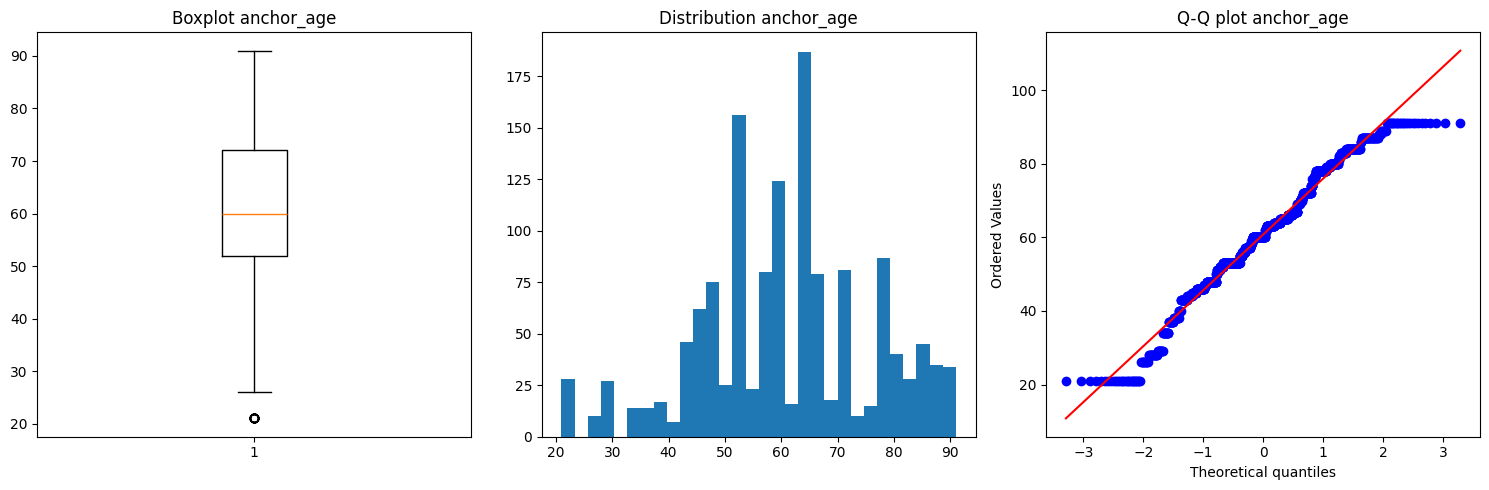

In [ ]:

plt.figure(figsize=(15, 5))

# Boxplot
plt.subplot(1, 3, 1)
plt.boxplot(df['anchor_age'])
plt.title('Boxplot anchor_age')

# Histogramme
plt.subplot(1, 3, 2)
plt.hist(df['anchor_age'], bins=30)
plt.title('Distribution anchor_age')

# QQ-plot pour tester la normalité
plt.subplot(1, 3, 3)
stats.probplot(df['anchor_age'], dist="norm", plot=plt)
plt.title('Q-Q plot anchor_age')

plt.tight_layout()
plt.show()





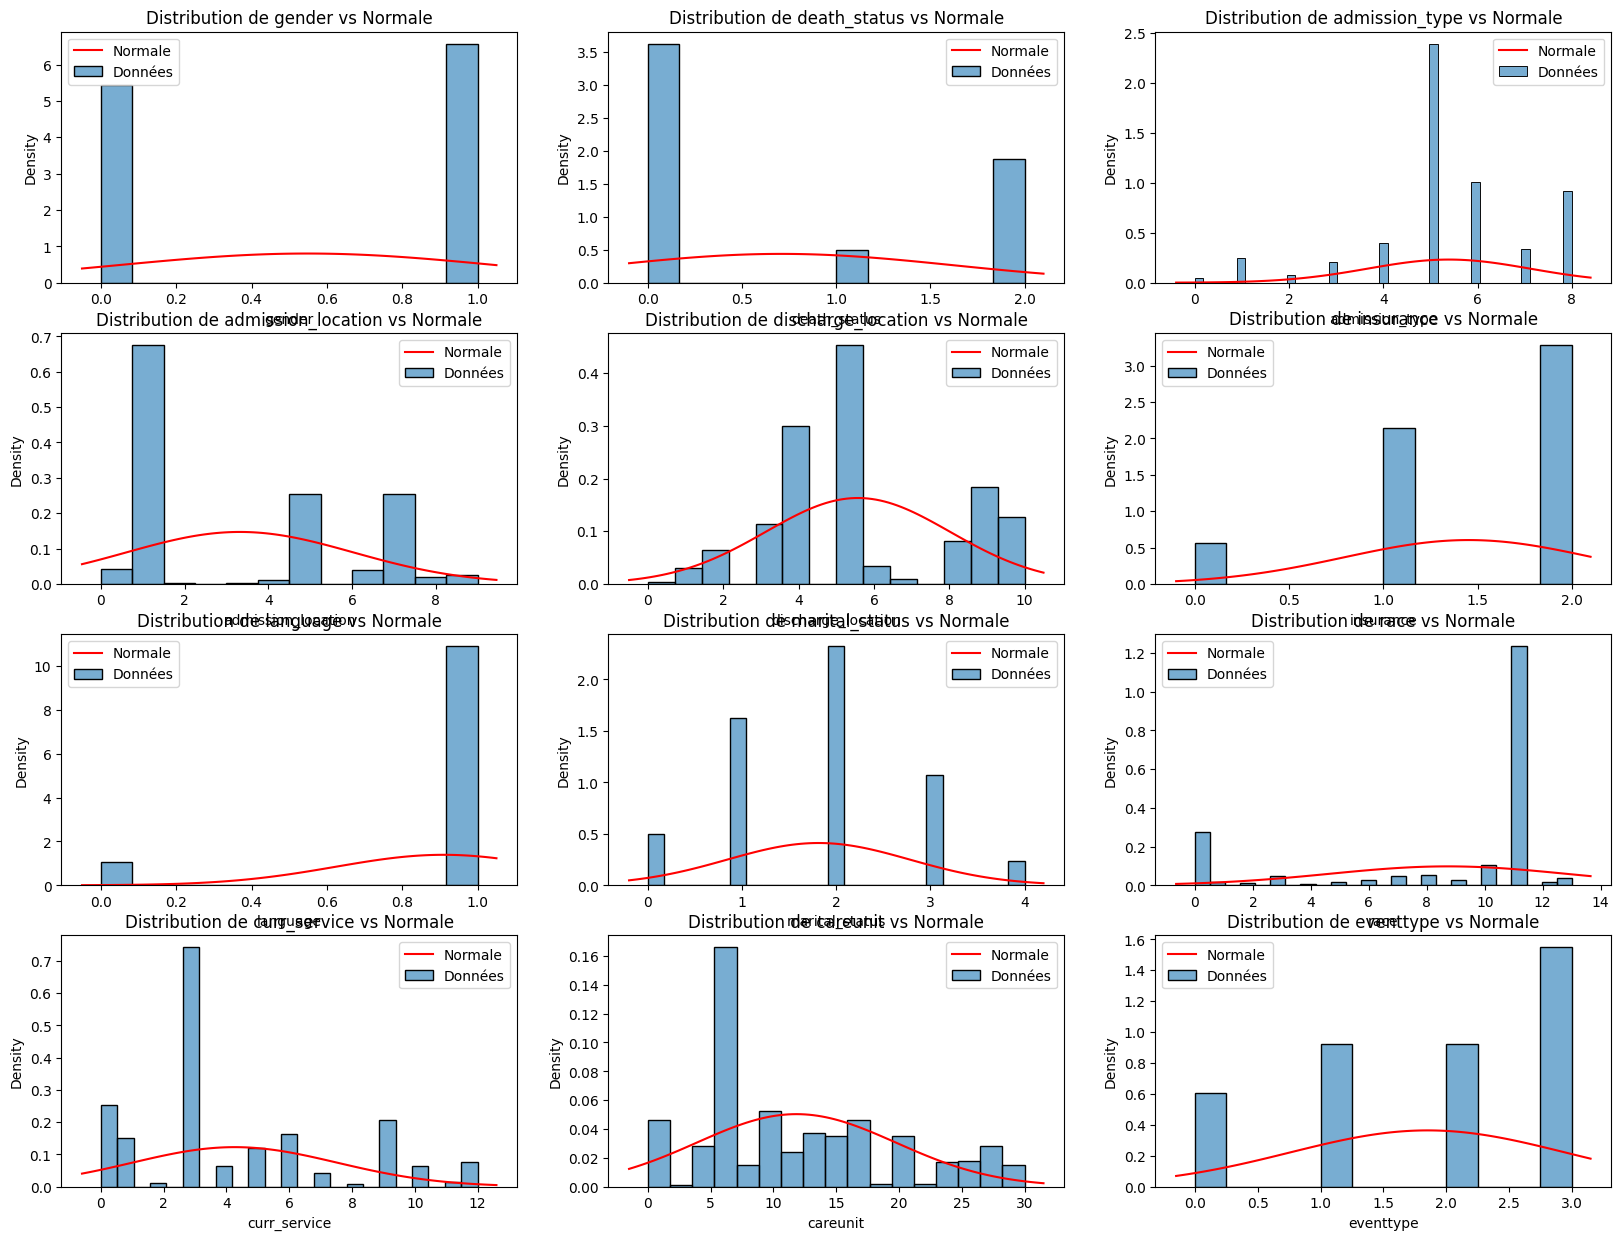

In [ ]:

cols_encoded = ['gender','death_status', 'admission_type', 'admission_location',
                'discharge_location', 'insurance', 'language', 'marital_status',
                'race', 'curr_service', 'careunit', 'eventtype']


plt.figure(figsize=(20, 15))
for idx, col in enumerate(cols_encoded, 1):
    plt.subplot(4, 3, idx)


    sns.histplot(df[col], stat='density', label='Données', alpha=0.6)


    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, df[col].mean(), df[col].std())
    plt.plot(x, p, 'r-', label='Normale')

    plt.title(f'Distribution de {col} vs Normale')
    plt.legend()

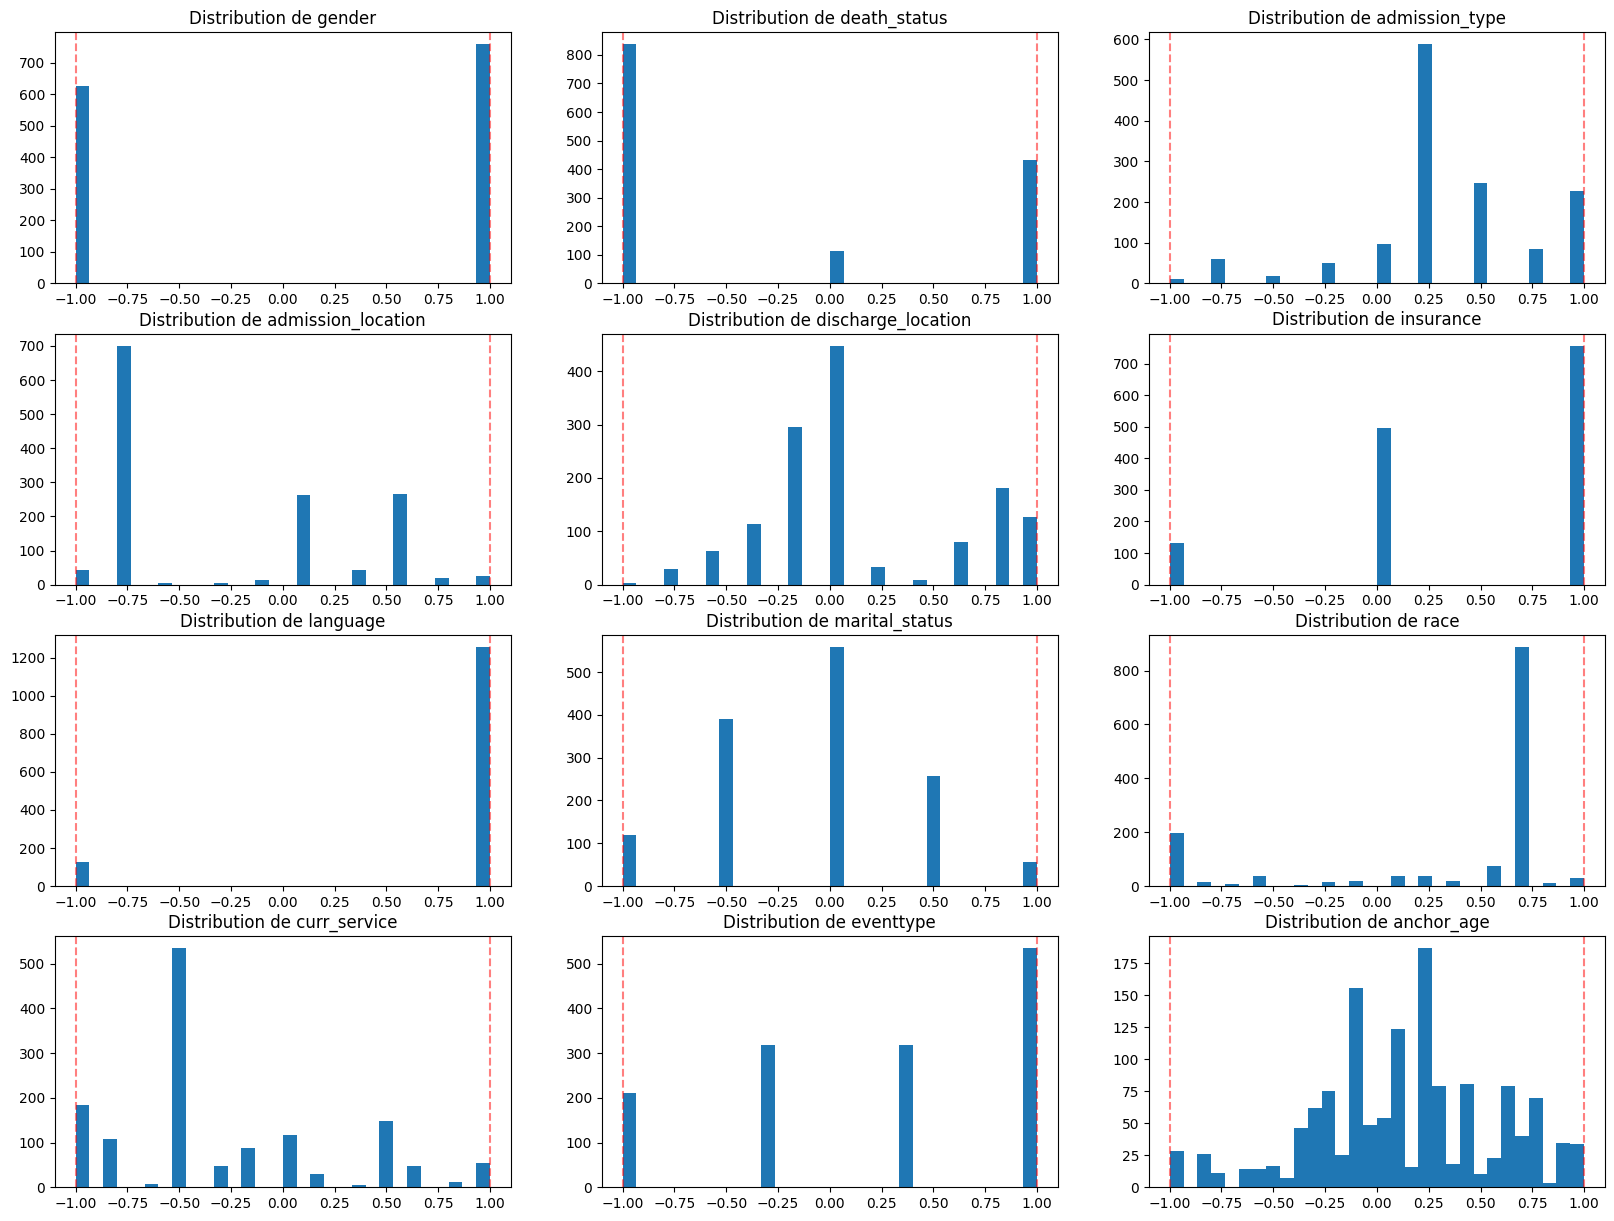

In [ ]:

cols_to_scale = ['gender', 'death_status', 'admission_type', 'admission_location',
                'discharge_location', 'insurance', 'language', 'marital_status',
                'race', 'curr_service', 'eventtype', 'anchor_age']


scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_values = scaler.fit_transform(df[cols_to_scale])


for i, col in enumerate(cols_to_scale):
    df[col] = scaled_values[:, i]


plt.figure(figsize=(20, 15))
for idx, col in enumerate(cols_to_scale, 1):
    plt.subplot(4, 3, idx)
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution de {col}')
    plt.axvline(x=-1, color='r', linestyle='--', alpha=0.5)
    plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)

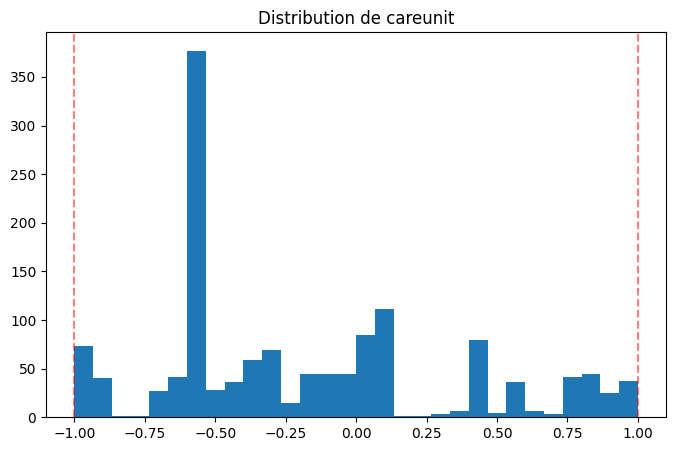


Ranges après scaling:
careunit: min=-1.000, max=1.000


In [ ]:

scaler = MinMaxScaler(feature_range=(-1, 1))
df['careunit'] = scaler.fit_transform(df[['careunit']])


plt.figure(figsize=(8, 5))
plt.hist(df['careunit'], bins=30)
plt.title('Distribution de careunit')
plt.axvline(x=-1, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='r', linestyle='--', alpha=0.5)
plt.show()

print("\nRanges après scaling:")
print(f"careunit: min={df['careunit'].min():.3f}, max={df['careunit'].max():.3f}")

In [ ]:
df.head(30)

,subject_id,hadm_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,language,marital_status,...,gender,anchor_age,curr_service,careunit,intime,outtime,eventtype,death_status,los_unit,los_total
0,10004235,24181354,1.0,0.555556,0.8,2196-02-24 14:38:00,2196-03-04 14:02:00,-1.0,1.0,0.0,...,1.0,-0.257143,-0.500000,-0.600000,2196-03-04 14:03:01,2196-03-04 14:02:00,0.333333,-1.0,-1.000000,-0.249303
1,10004235,24181354,1.0,0.555556,0.8,2196-02-24 14:38:00,2196-03-04 14:02:00,-1.0,1.0,0.0,...,1.0,-0.257143,-0.500000,0.000000,2196-02-29 15:58:02,2196-03-04 14:03:01,1.000000,-1.0,0.431986,-0.249303
2,10004235,24181354,1.0,0.555556,0.8,2196-02-24 14:38:00,2196-03-04 14:02:00,-1.0,1.0,0.0,...,1.0,-0.257143,-0.500000,-0.600000,2196-02-24 12:15:00,2196-02-24 17:07:00,-1.000000,-1.0,-0.940515,-0.249303
3,10004235,24181354,1.0,0.555556,0.8,2196-02-24 14:38:00,2196-03-04 14:02:00,-1.0,1.0,0.0,...,1.0,-0.257143,-0.500000,-0.733333,2196-02-24 17:07:00,2196-02-25 23:35:26,-0.333333,-1.0,-0.546575,-0.249303
4,10004235,24181354,1.0,0.555556,0.8,2196-02-24 14:38:00,2196-03-04 14:02:00,-1.0,1.0,0.0,...,1.0,-0.257143,-0.500000,-0.133333,2196-02-25 23:35:26,2196-02-29 15:58:02,1.000000,-1.0,0.344199,-0.249303
5,10009628,25926192,1.0,0.555556,0.0,2153-09-17 17:08:00,2153-09-25 13:20:00,-1.0,-1.0,-0.5,...,1.0,0.057143,-0.833333,-1.000000,2153-09-25 13:24:22,2153-09-25 13:20:00,0.333333,-1.0,-1.000000,-0.344593
6,10009628,25926192,1.0,0.555556,0.0,2153-09-17 17:08:00,2153-09-25 13:20:00,-1.0,-1.0,-0.5,...,1.0,0.057143,-0.833333,-1.000000,2153-09-17 17:08:47,2153-09-19 09:54:49,-0.333333,-1.0,-0.388223,-0.344593
7,10009628,25926192,1.0,0.555556,0.0,2153-09-17 17:08:00,2153-09-25 13:20:00,-1.0,-1.0,-0.5,...,1.0,0.057143,-0.833333,-1.000000,2153-09-21 16:39:06,2153-09-25 13:24:22,1.000000,-1.0,0.411547,-0.344593
8,10009628,25926192,1.0,0.555556,0.0,2153-09-17 17:08:00,2153-09-25 13:20:00,-1.0,-1.0,-0.5,...,1.0,0.057143,-0.833333,-0.933333,2153-09-19 09:54:49,2153-09-21 16:39:06,1.000000,-1.0,-0.173296,-0.344593
9,10018081,23983182,1.0,0.555556,0.8,2134-08-18 02:02:00,2134-08-23 19:35:00,0.0,1.0,-0.5,...,1.0,0.657143,0.500000,-0.600000,2134-08-23 19:35:09,2134-08-23 19:35:00,0.333333,1.0,-1.000000,-0.522034


## Correlation Analysis
We examine correlations between the scaled features using a heatmap and summary statistics. This helps identify relationships and potential multicollinearity, guiding feature selection for modeling.

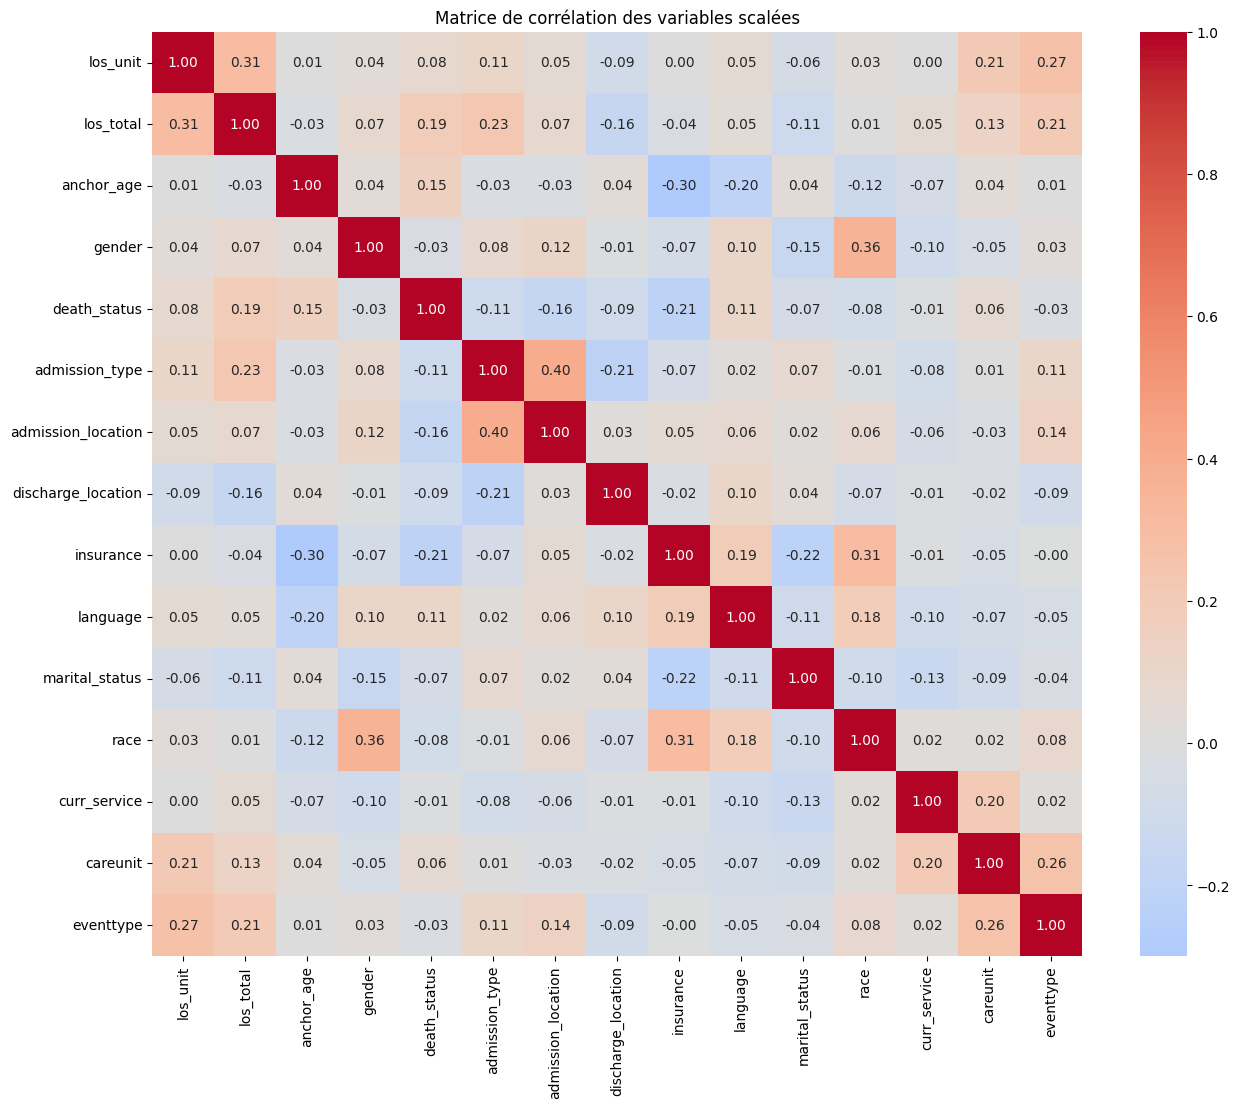


Corrélations les plus fortes (>0.5 ou <-0.5):


In [ ]:

corr_df = df[['los_unit', 'los_total', 'anchor_age', 'gender', 'death_status',
              'admission_type', 'admission_location', 'discharge_location',
              'insurance', 'language', 'marital_status', 'race',
              'curr_service', 'careunit', 'eventtype']]


plt.figure(figsize=(15, 12))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de corrélation des variables scalées')
plt.show()

print("\nCorrélations les plus fortes (>0.5 ou <-0.5):")
corr_matrix = corr_df.corr()
for column in corr_matrix.columns:
    correlations = corr_matrix[column]
    strong_corr = correlations[(abs(correlations) > 0.5) & (correlations != 1.0)]
    if not strong_corr.empty:
        print(f"\n{column}:")
        print(strong_corr)

## Prepare Data for PCA
We drop time-related columns (`admittime`, `dischtime`, `intime`, `outtime`) since we calculated from them the desired information (los-careunit and los_total) and identifiers (`subject_id`, `hadm_id`) to prepare the dataset for Principal Component Analysis (PCA). This ensures only relevant, numeric features are used for dimensionality reduction.

In [ ]:



df = df.drop(['admittime', 'dischtime', 'intime', 'outtime'], axis=1)



In [ ]:

df = df.drop(['subject_id', 'hadm_id'], axis=1)


In [ ]:
df.head()

,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,gender,anchor_age,curr_service,careunit,eventtype,death_status,los_unit,los_total
0,1.0,0.555556,0.8,-1.0,1.0,0.0,-0.846154,1.0,-0.257143,-0.5,-0.600000,0.333333,-1.0,-1.000000,-0.249303
1,1.0,0.555556,0.8,-1.0,1.0,0.0,-0.846154,1.0,-0.257143,-0.5,0.000000,1.000000,-1.0,0.431986,-0.249303
2,1.0,0.555556,0.8,-1.0,1.0,0.0,-0.846154,1.0,-0.257143,-0.5,-0.600000,-1.000000,-1.0,-0.940515,-0.249303
3,1.0,0.555556,0.8,-1.0,1.0,0.0,-0.846154,1.0,-0.257143,-0.5,-0.733333,-0.333333,-1.0,-0.546575,-0.249303
4,1.0,0.555556,0.8,-1.0,1.0,0.0,-0.846154,1.0,-0.257143,-0.5,-0.133333,1.000000,-1.0,0.344199,-0.249303


## Principal Component Analysis (PCA)
We apply PCA to reduce the dimensionality of the dataset while retaining as much variance as possible. This step:
- Computes principal components and their explained variance.
- Visualizes eigenvalues (scree plot) and cumulative explained variance.
- Helps determine the optimal number of components for downstream analysis.

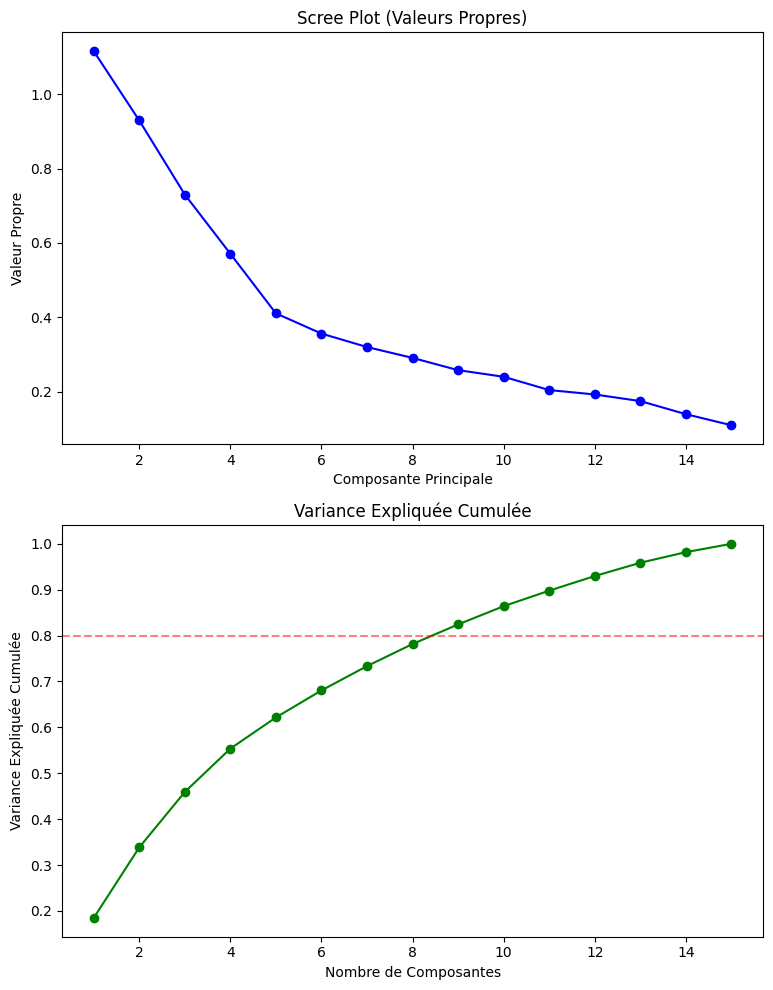


Valeurs propres:
PC1: 1.1161
PC2: 0.9295
PC3: 0.7303
PC4: 0.5711
PC5: 0.4108
PC6: 0.3564
PC7: 0.3202
PC8: 0.2910
PC9: 0.2581
PC10: 0.2403
PC11: 0.2045
PC12: 0.1927
PC13: 0.1749
PC14: 0.1397
PC15: 0.1099

Variance expliquée (%):
PC1: 18.46%
PC2: 15.38%
PC3: 12.08%
PC4: 9.45%
PC5: 6.79%
PC6: 5.90%
PC7: 5.30%
PC8: 4.81%
PC9: 4.27%
PC10: 3.97%
PC11: 3.38%
PC12: 3.19%
PC13: 2.89%
PC14: 2.31%
PC15: 1.82%

Nombre de composantes pour:
80% de variance: 9
90% de variance: 12


In [ ]:


pca = PCA()
pca_result = pca.fit_transform(df)


eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

plt.figure(figsize=(15, 10))

#scree
plt.subplot(2, 2, 1)
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-')
plt.title('Scree Plot (Valeurs Propres)')
plt.xlabel('Composante Principale')
plt.ylabel('Valeur Propre')




#var cumulée
plt.subplot(2, 2, 3)
cum_var_ratio = np.cumsum(var_ratio)
plt.plot(range(1, len(cum_var_ratio) + 1), cum_var_ratio, 'go-')
plt.axhline(y=0.8, color='r', linestyle='--', alpha=0.5)
plt.title('Variance Expliquée Cumulée')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Expliquée Cumulée')

plt.tight_layout()
plt.show()


print("\nValeurs propres:")
for i, val in enumerate(eigenvalues, 1):
    print(f"PC{i}: {val:.4f}")

print("\nVariance expliquée (%):")
for i, var in enumerate(var_ratio * 100, 1):
    print(f"PC{i}: {var:.2f}%")

print("\nNombre de composantes pour:")
print(f"80% de variance: {np.where(cum_var_ratio >= 0.8)[0][0] + 1}")
print(f"90% de variance: {np.where(cum_var_ratio >= 0.9)[0][0] + 1}")

In [ ]:
cov_matrix = np.cov(df.T)

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [ ]:
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [ ]:
feature_vector = eigenvectors

Text(0, 0.5, 'Valeur Propre')

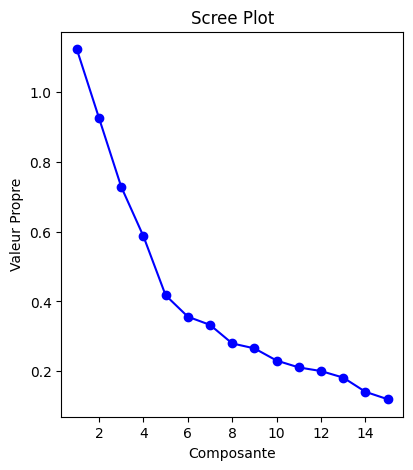

In [ ]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, 'bo-')
plt.title('Scree Plot')
plt.xlabel('Composante')
plt.ylabel('Valeur Propre')

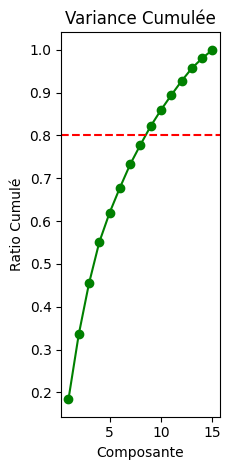

In [ ]:
cum_var_exp = np.cumsum(var_exp)
plt.subplot(1, 3, 3)
plt.plot(range(1, len(cum_var_exp) + 1), cum_var_exp, 'go-')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title('Variance Cumulée')
plt.xlabel('Composante')
plt.ylabel('Ratio Cumulé')

plt.tight_layout()
plt.show()

In [ ]:
k = np.where(cum_var_exp >= 0.8)[0][0] + 1
print(f"Nombre de composantes pour 80% de variance: {k}")

Nombre de composantes pour 80% de variance: 9


In [ ]:

final_feature_vector = feature_vector[:, :k]

df_pca = pd.DataFrame(
    np.dot(df, final_feature_vector),
    columns=[f'PC{i+1}' for i in range(9)],
    index=df.index
)

print("Shape df original:", df.shape)
print("Shape df_pca:", df_pca.shape)

Shape df original: (1383, 15)
Shape df_pca: (1383, 9)


In [ ]:
df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-0.957245,-0.657963,0.603670,-1.353815,-1.170867,-0.610053,0.245194,0.247645,1.687027
1,-1.104562,-0.338353,-0.726376,-1.467695,-1.053931,0.050732,-0.162231,0.165876,1.639917
2,-0.832065,-0.722856,1.491691,-1.156462,-1.350077,0.188561,0.557361,0.031295,1.465240
3,-0.924352,-0.630474,0.876506,-1.252128,-1.346315,0.081255,0.283706,0.169198,1.496466
4,-1.101101,-0.362978,-0.646041,-1.464433,-1.085266,-0.017768,-0.161298,0.204133,1.638680


In [ ]:
df.head()

,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,gender,anchor_age,curr_service,careunit,eventtype,death_status,los_unit,los_total
0,1.0,0.555556,1.0,-1.0,1.0,0.333333,-0.846154,1.0,-0.257143,-0.5,-0.600000,0.333333,-1.0,-1.000000,-0.249303
1,1.0,0.555556,1.0,-1.0,1.0,0.333333,-0.846154,1.0,-0.257143,-0.5,0.000000,1.000000,-1.0,0.431986,-0.249303
2,1.0,0.555556,1.0,-1.0,1.0,0.333333,-0.846154,1.0,-0.257143,-0.5,-0.600000,-1.000000,-1.0,-0.940515,-0.249303
3,1.0,0.555556,1.0,-1.0,1.0,0.333333,-0.846154,1.0,-0.257143,-0.5,-0.733333,-0.333333,-1.0,-0.546575,-0.249303
4,1.0,0.555556,1.0,-1.0,1.0,0.333333,-0.846154,1.0,-0.257143,-0.5,-0.133333,1.000000,-1.0,0.344199,-0.249303
